In [2]:
# Install required packages (uncomment as needed)
# !pip install transformers datasets scikit-learn torch evaluate accelerate
# !pip install sentencepiece  # needed for some tokenizers
# !pip install -U adapters transformers huggingface_hub  # needed for adapter

# Core imports
import random
import numpy as np
import pandas as pd

# HuggingFace
from datasets import load_dataset
from transformers import AutoTokenizer, TrainingArguments, Trainer, AutoModelForSeq2SeqLM

# Scikit-learn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.model_selection import train_test_split

# misc
import torch
import adapters
from adapters import LoRAConfig, AutoAdapterModel

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

## load dataset and explore

In [3]:
dataset = load_dataset('csv', data_files={'train': 'codabench-starter-kit/dataset/train.csv', 'val': 'codabench-starter-kit/dataset/validation.csv', 'test': 'codabench-starter-kit/dataset/test.csv'})

# convert lang to labels
dataset = dataset.rename_column("lang", "labels")

print(dataset)

# convert labels to integers
dataset = dataset.class_encode_column("labels")

# print some example instances
print("\nExample datapoints:")
print(dataset['train'][:5])

Generating train split: 0 examples [00:00, ? examples/s]

Generating val split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'text', 'labels'],
        num_rows: 60000
    })
    val: Dataset({
        features: ['id', 'text', 'labels'],
        num_rows: 24396
    })
    test: Dataset({
        features: ['id', 'text', 'labels'],
        num_rows: 35688
    })
})


Casting to class labels:   0%|          | 0/60000 [00:00<?, ? examples/s]

Casting to class labels:   0%|          | 0/24396 [00:00<?, ? examples/s]

Casting to class labels:   0%|          | 0/35688 [00:00<?, ? examples/s]


Example datapoints:
{'id': [0, 1, 2, 3, 4], 'text': ['ci sono lavori in corso sulla a quattordici', 'schlummer alle heutigen wecker permanent', 'gibt es irgendwelche status updates von tagesschau nachrichten auf der facebook seite', 'hur många kalorier är det i en apelsin', 'sei stumm'], 'labels': [6, 1, 1, 9, 1]}


## load model

In [4]:
# Load tokenizer and model
MODEL_1_NAME = "FacebookAI/roberta-base"

tokenizer_1 = AutoTokenizer.from_pretrained(MODEL_1_NAME)
model_1 = AutoAdapterModel.from_pretrained(MODEL_1_NAME)

#
adapters.init(model_1)
config = LoRAConfig(r=8, alpha=16)
model_1.add_adapter("lora_adapter", config=config)
model_1.add_classification_head("lora_adapter", num_labels=12) # 12 languages
model_1.set_active_adapters("lora_adapter")
model_1.train_adapter("lora_adapter")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaAdapterModel were not initialized from the model checkpoint at FacebookAI/roberta-base and are newly initialized: ['heads.default.3.bias', 'roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [5]:
# Tokenize the dataset for Model 1
def tokenize(examples):
  # decreased max length bc colab kept crashing (but now my accuracy will be worse)
    return tokenizer_1(examples['text'], truncation=True, padding='max_length', max_length=124)

train_tokens = dataset['train'].map(tokenize, batched=True)
eval_tokens = dataset['val'].map(tokenize, batched=True)
test_tokens = dataset['test'].map(tokenize, batched=True)

Map:   0%|          | 0/60000 [00:00<?, ? examples/s]

Map:   0%|          | 0/24396 [00:00<?, ? examples/s]

Map:   0%|          | 0/35688 [00:00<?, ? examples/s]

In [7]:
# Define training arguments and Trainer, then fine-tune Model 3
training_args = TrainingArguments(
    num_train_epochs=5,              # defaulted to 3, changed to 5
    per_device_train_batch_size=32,
    gradient_accumulation_steps=1,
    learning_rate=1e-4,              # default 5e-5
    lr_scheduler_type="cosine",
    optim="adamw_torch",             # Specify a non-fused optimizer for XLA compatibility
    weight_decay=0.01,
    report_to="none",                # resolve wandb error
    label_names=["labels"]           # new because... loss wasn't being calculated
)

# train_subset = train_tokens.shuffle(seed=SEED).select(range(5000))

trainer = Trainer(
    model=model_1,
    args=training_args,
    train_dataset=train_tokens,
    eval_dataset=eval_tokens,
)

trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Step,Training Loss
500,0.594700
1000,0.255100
1500,0.221900
2000,0.195600
2500,0.177600
3000,0.157100
3500,0.151200
4000,0.142800
4500,0.129800
5000,0.134600


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


TrainOutput(global_step=9375, training_loss=0.169287041015625, metrics={'train_runtime': 890.9791, 'train_samples_per_second': 336.708, 'train_steps_per_second': 10.522, 'total_flos': 1.94594056344e+16, 'train_loss': 0.169287041015625, 'epoch': 5.0})

In [8]:
# Evaluate Model on the test split
results = trainer.evaluate()

# predict labels for test ser
prediction_output = trainer.predict(test_tokens)
logits = prediction_output.predictions
if isinstance(prediction_output.predictions, tuple):
    logits = logits[0]

prediction_id = np.argmax(logits, axis=1)

# csv for codabench submission
submission_df = pd.DataFrame(prediction_id, columns=['label'])
submission_df.to_csv('predictions.csv', index=False)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


In [9]:
# add id column to predictions (start at 0)
submission_df = pd.read_csv('predictions.csv')
submission_df.insert(0, 'id', range(len(submission_df)))
submission_df.to_csv('predictions.csv', index=False)

# map label back to lang and rename label column to lang
submission_df['label'] = submission_df['label'].map(dataset['train'].features['labels'].int2str)
submission_df = submission_df.rename(columns={'label': 'lang'})

# replace label column with lang
submission_df.to_csv('prediction_results.csv', index=False)

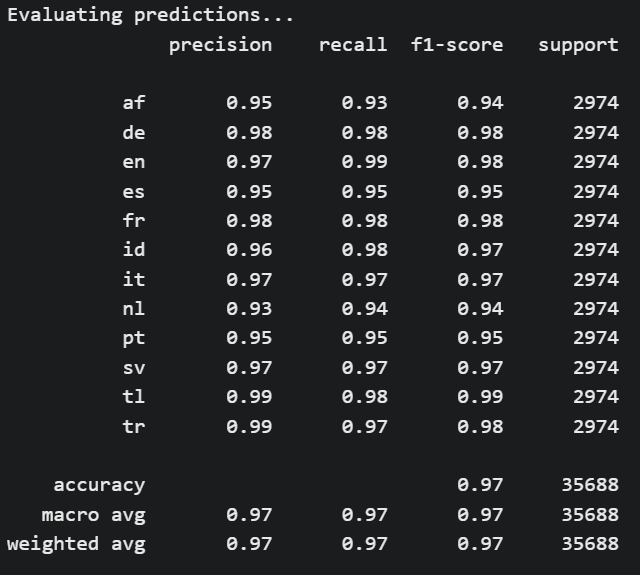